In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# Set visualization style
sns.set_style("whitegrid")

In [13]:
df = pd.read_excel("/content/1730285881-Airbnb_Open_Data.xlsx")

In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 102599 entries, 0 to 102598
Data columns (total 26 columns):
 #   Column                          Non-Null Count   Dtype         
---  ------                          --------------   -----         
 0   id                              102599 non-null  int64         
 1   NAME                            102329 non-null  object        
 2   host id                         102599 non-null  int64         
 3   host_identity_verified          102310 non-null  object        
 4   host name                       102191 non-null  object        
 5   neighbourhood group             102570 non-null  object        
 6   neighbourhood                   102583 non-null  object        
 7   lat                             102591 non-null  float64       
 8   long                            102591 non-null  float64       
 9   country                         102067 non-null  object        
 10  country code                    102468 non-null  object 

In [15]:
#Standardizing Column Names (Replace spaces and uppercase with snake_case)
df.columns = df.columns.str.lower().str.replace(' ', '_')

In [16]:
# Fill missing host_identity_verified with 'unknown'
df['host_identity_verified'].fillna('unknown', inplace=True)

# Fill missing host_name with 'No Name'
df['host_name'].fillna('No Name', inplace=True)


/tmp/ipython-input-2821065261.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['host_identity_verified'].fillna('unknown', inplace=True)
/tmp/ipython-input-2821065261.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=Tr

In [17]:
# Fill missing review-related columns with 0, as NaN likely means no reviews
df['number_of_reviews'].fillna(0, inplace=True)
df['reviews_per_month'].fillna(0, inplace=True)
df['last_review'].fillna('1970-01-01', inplace=True)

# Fill missing review_rate_number with the median, as this is a quality metric
median_rate = df['review_rate_number'].median()
df['review_rate_number'].fillna(median_rate, inplace=True)

# Drop columns with too many unique/missing values or low relevance for core analysis
cols_to_drop = ['id', 'host_id', 'country', 'country_code', 'license', 'house_rules']
df.drop(columns=cols_to_drop, inplace=True, errors='ignore')
print(f"\nDropped columns: {cols_to_drop}")


Dropped columns: ['id', 'host_id', 'country', 'country_code', 'license', 'house_rules']


/tmp/ipython-input-3163080328.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['number_of_reviews'].fillna(0, inplace=True)
/tmp/ipython-input-3163080328.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try usi

In [18]:
def clean_numeric_column(series):
    # Remove non-numeric characters like '$' and ','
    if series.dtype == 'object':
        series = series.astype(str).str.replace('$', '', regex=False).str.replace(',', '', regex=False)
    # Convert to numeric, setting errors='coerce' to turn problematic values into NaN
    return pd.to_numeric(series, errors='coerce')

df['price'] = clean_numeric_column(df['price'])
df['service_fee'] = clean_numeric_column(df['service_fee'])

In [19]:
df.dropna(subset=['price', 'service_fee'], inplace=True)
df = df[(df['price'] > 10) & (df['price'] < df['price'].quantile(0.99))]
df = df[(df['service_fee'] >= 0)]

# Convert construction_year to integer, filling missing with median for imputation
df['construction_year'].fillna(df['construction_year'].median(), inplace=True)
df['construction_year'] = df['construction_year'].astype(int)

/tmp/ipython-input-796082585.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['construction_year'].fillna(df['construction_year'].median(), inplace=True)


In [20]:
df.head()

,name,host_identity_verified,host_name,neighbourhood_group,neighbourhood,lat,long,instant_bookable,cancellation_policy,room_type,construction_year,price,service_fee,minimum_nights,number_of_reviews,last_review,reviews_per_month,review_rate_number,calculated_host_listings_count,availability_365
0,Clean & quiet apt home by the park,unconfirmed,Madaline,Brooklyn,Kensington,40.64749,-73.97237,0.0,strict,Private room,2020,966.0,193.0,10.0,9.0,2021-10-19,0.21,4.0,6.0,286.0
1,Skylit Midtown Castle,verified,Jenna,Manhattan,Midtown,40.75362,-73.98377,0.0,moderate,Entire home/apt,2007,142.0,28.0,30.0,45.0,2022-05-21,0.38,4.0,2.0,228.0
2,THE VILLAGE OF HARLEM....NEW YORK !,unknown,Elise,Manhattan,Harlem,40.80902,-73.94190,1.0,flexible,Private room,2005,620.0,124.0,3.0,0.0,1970-01-01,0.00,5.0,1.0,352.0
3,NaN,unconfirmed,Garry,Brooklyn,Clinton Hill,40.68514,-73.95976,1.0,moderate,Entire home/apt,2005,368.0,74.0,30.0,270.0,2019-07-05,4.64,4.0,1.0,322.0
4,Entire Apt: Spacious Studio/Loft by central park,verified,Lyndon,Manhattan,East Harlem,40.79851,-73.94399,0.0,moderate,Entire home/apt,2009,204.0,41.0,10.0,9.0,2018-11-19,0.10,3.0,1.0,289.0


In [21]:
df.shape

(101008, 20)

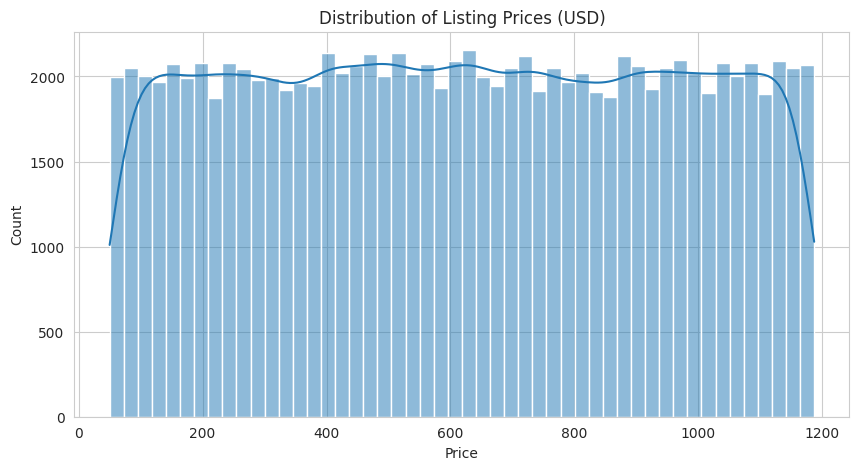

In [22]:
#Distribution of Price
plt.figure(figsize=(10, 5))
sns.histplot(df['price'], bins=50, kde=True)
plt.title('Distribution of Listing Prices (USD)')
plt.xlabel('Price')
plt.ylabel('Count')
plt.show()

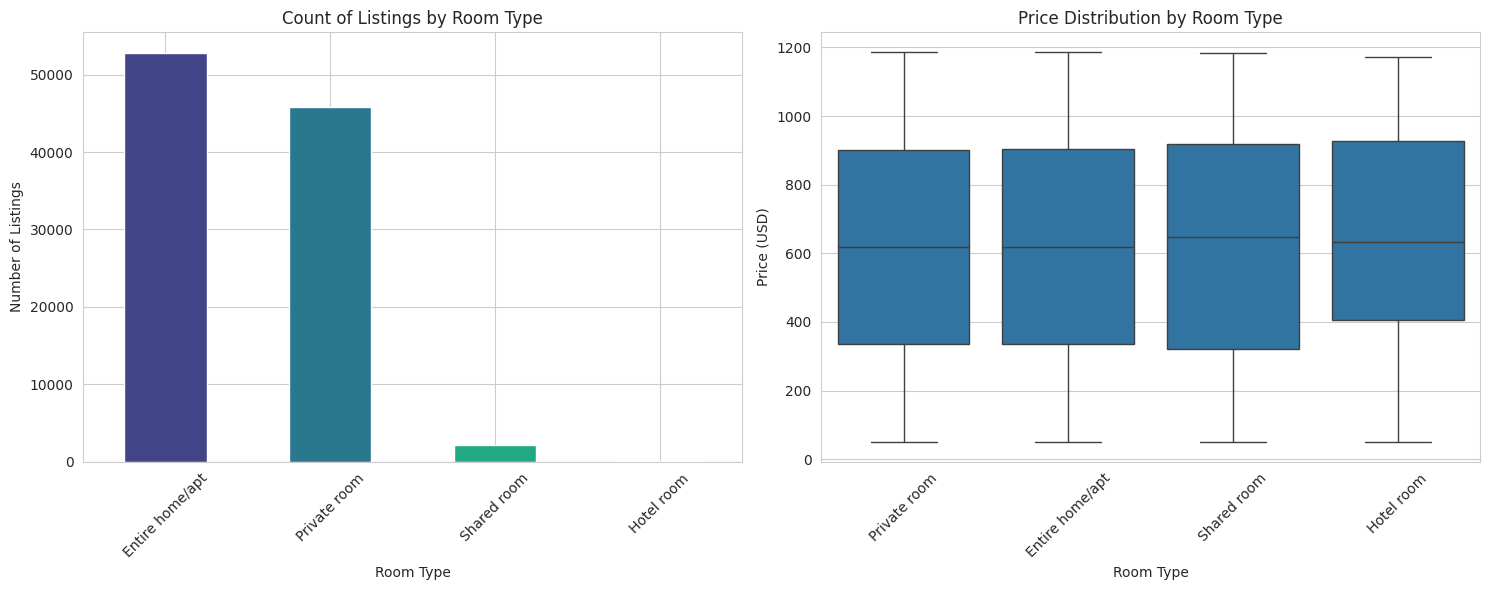

In [23]:
# Room Type Popularity and Pricing
plt.figure(figsize=(15, 6))

plt.subplot(1, 2, 1)
df['room_type'].value_counts().plot(kind='bar', color=sns.color_palette("viridis", 4))
plt.title('Count of Listings by Room Type')
plt.xlabel('Room Type')
plt.ylabel('Number of Listings')
plt.xticks(rotation=45)

plt.subplot(1, 2, 2)
sns.boxplot(x='room_type', y='price', data=df)
plt.title('Price Distribution by Room Type')
plt.xlabel('Room Type')
plt.ylabel('Price (USD)')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()


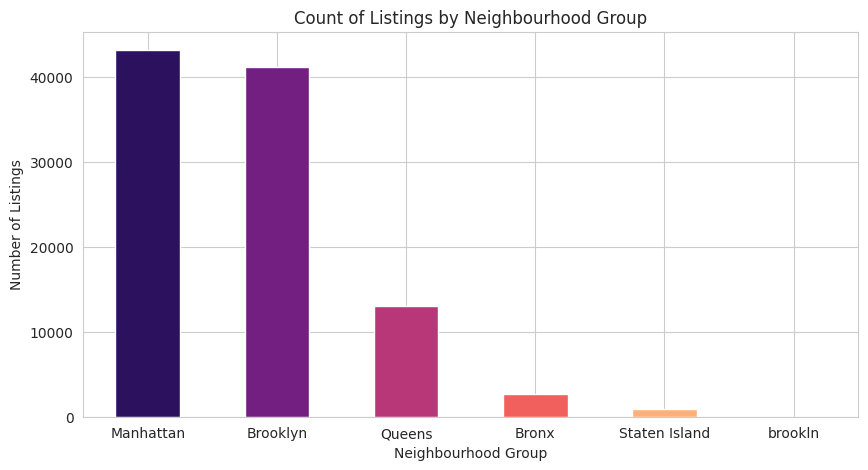

In [24]:
# Geographical Distribution (Neighbourhood Group)
plt.figure(figsize=(10, 5))
df['neighbourhood_group'].value_counts().plot(kind='bar', color=sns.color_palette("magma", 5))
plt.title('Count of Listings by Neighbourhood Group')
plt.xlabel('Neighbourhood Group')
plt.ylabel('Number of Listings')
plt.xticks(rotation=0)
plt.show()

In [25]:
# Top 10 Neighbourhoods by Number of Reviews (High Demand)
top_demand_neighbourhoods = df.groupby('neighbourhood').agg(
    Total_Reviews=('number_of_reviews', 'sum'),
    Avg_Review_Rate=('review_rate_number', 'mean'),
    Avg_Price=('price', 'mean')
).sort_values(by='Total_Reviews', ascending=False).head(10)

print("\n3.3.1 Top 10 Neighbourhoods by Total Reviews (Demand Hotspots):")
print(top_demand_neighbourhoods.style.format({
    'Avg_Review_Rate': '{:.2f}',
    'Avg_Price': '${:.2f}'
}).to_string())


3.3.1 Top 10 Neighbourhoods by Total Reviews (Demand Hotspots):
 Total_Reviews Avg_Review_Rate Avg_Price
neighbourhood   
Bedford-Stuyvesant 269016.000000 3.28 $615.15
Williamsburg 188226.000000 3.25 $618.79
Harlem 177717.000000 3.23 $620.26
Bushwick 122374.000000 3.28 $625.90
Hell's Kitchen 110664.000000 3.28 $616.26
East Village 96837.000000 3.26 $613.32
Crown Heights 88384.000000 3.29 $611.14
East Harlem 82337.000000 3.32 $623.63
Upper West Side 76754.000000 3.24 $610.20
Upper East Side 69432.000000 3.25 $614.58



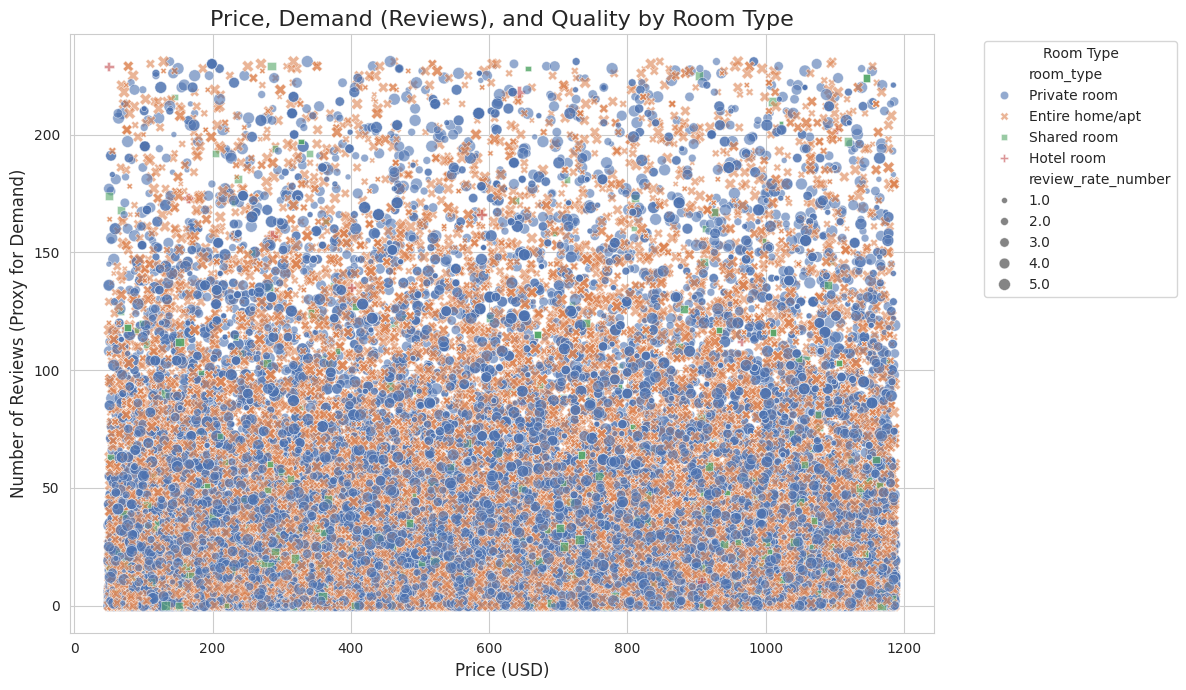

In [27]:
# Price vs. Reviews by Room Type (Scatter Plot)
df_viz = df[df['number_of_reviews'] < df['number_of_reviews'].quantile(0.99)]

plt.figure(figsize=(12, 7))
sns.scatterplot(
    data=df_viz,
    x='price',
    y='number_of_reviews',
    hue='room_type',
    style='room_type',
    size='review_rate_number',
    alpha=0.6,
    palette='deep'
)
plt.title('Price, Demand (Reviews), and Quality by Room Type', fontsize=16)
plt.xlabel('Price (USD)', fontsize=12)
plt.ylabel('Number of Reviews (Proxy for Demand)', fontsize=12)
plt.legend(title='Room Type', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig('viz_price_demand_roomtype.png')
plt.show()

/tmp/ipython-input-760482720.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


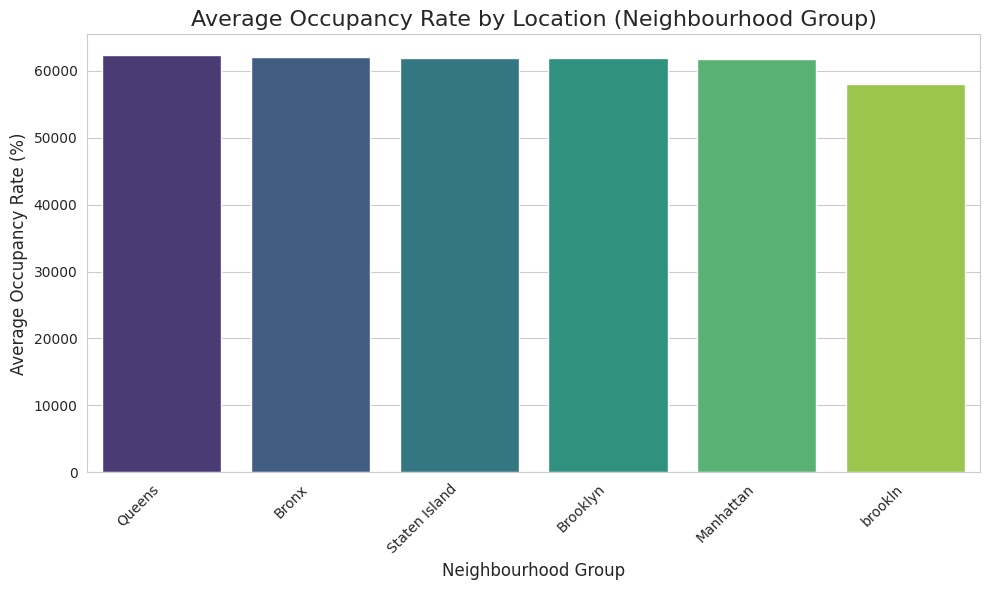

In [34]:
 #Average Occupancy Rate by Neighbourhood Group (Bar Plot)

occupancy_by_group = df.groupby('neighbourhood_group')['price'].mean().sort_values(ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(
    x=occupancy_by_group.index,
    y=occupancy_by_group.values * 100,
    palette='viridis'
)
plt.title('Average Occupancy Rate by Location (Neighbourhood Group)', fontsize=16)
plt.xlabel('Neighbourhood Group', fontsize=12)
plt.ylabel('Average Occupancy Rate (%)', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('viz_occupancy_by_location.png')
plt.show()